In [53]:
#Import all relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
 
## This statement allows the visuals to render within your Jupyter Notebook.
%matplotlib inline

## Loading the data
We can now load the dataset into pandas using the read_csv() function. This converts the CSV file into a Pandas dataframe.

In [129]:
# Load Datasets
WH15 = pd.read_csv("2015.csv")
WH16 = pd.read_csv("2016.csv")
WH17 = pd.read_csv("2017.csv")
WH18 = pd.read_csv("2018.csv")
WH19 = pd.read_csv("2019.csv")

#Read in the csv file and convert to a Pandas dataframe
dataframes = {
    'Wolrd Happines 2015': WH15,
    'Wolrd Happines 2016': WH16,
    'Wolrd Happines 2017': WH17,
    'Wolrd Happines 2018': WH18,
    'Wolrd Happines 2019': WH19
}

### Viewing the dataframe
We can get a quick sense of the size of our dataset by using the shape method. This returns a tuple with the number of rows and columns in the dataset.

In [81]:
# Viewing the DataFrame shape
for name, data in dataframes.items():
    print(f"\n{name} \n", data.shape)


Wolrd Happines 2015 
 (158, 12)

Wolrd Happines 2016 
 (157, 13)

Wolrd Happines 2017 
 (155, 12)

Wolrd Happines 2018 
 (156, 9)

Wolrd Happines 2019 
 (156, 9)


In [82]:
# Viewing the DataFrame data types
for name, data in dataframes.items():
    print(f"\n{name} :\n", data.columns)


Wolrd Happines 2015 :
 Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual'],
      dtype='object')

Wolrd Happines 2016 :
 Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Lower Confidence Interval', 'Upper Confidence Interval',
       'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)',
       'Freedom', 'Trust (Government Corruption)', 'Generosity',
       'Dystopia Residual'],
      dtype='object')

Wolrd Happines 2017 :
 Index(['Country', 'Happiness Rank', 'Happiness Score', 'Whisker.high',
       'Whisker.low', 'Economy..GDP.per.Capita.', 'Family',
       'Health..Life.Expectancy.', 'Freedom', 'Generosity',
       'Trust..Government.Corruption.', 'Dystopia.Residual'],
      dtype='object')

Wolrd Happines 2018 :
 Index(['Happiness Rank', 'Country', 'H

In [159]:
WH18.rename(columns={'Score':'Happiness Score'},inplace=True)

In [161]:
WH17

,Country,Happiness Rank,Happiness Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182
...,...,...,...,...,...,...,...,...,...,...,...,...
150,Rwanda,151,3.471,3.543030,3.398970,0.368746,0.945707,0.326425,0.581844,0.252756,0.455220,0.540061
151,Syria,152,3.462,3.663669,3.260331,0.777153,0.396103,0.500533,0.081539,0.493664,0.151347,1.061574
152,Tanzania,153,3.349,3.461430,3.236570,0.511136,1.041990,0.364509,0.390018,0.354256,0.066035,0.621130
153,Burundi,154,2.905,3.074690,2.735310,0.091623,0.629794,0.151611,0.059901,0.204435,0.084148,1.683024


## 1. Data Profiling:
Data profiling is a comprehensive process of examining the data available in an existing dataset and collecting statistics and information about that data. 

In [78]:
# Viewing the DataFrame info
for name, data in dataframes.items():
    print(f"\n{name} - Info:\n", data.info())
    print("-" * 50 )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

In [83]:
# Viewing the DataFrame types
for name, data in dataframes.items():
    print(f"\n{name} - Description:\n", data.describe(include='object'))
    print("-" * 50 )


Wolrd Happines 2015 - Description:
             Country              Region
count           158                 158
unique          158                  10
top     Switzerland  Sub-Saharan Africa
freq              1                  40
--------------------------------------------------

Wolrd Happines 2016 - Description:
         Country              Region
count       157                 157
unique      157                  10
top     Denmark  Sub-Saharan Africa
freq          1                  38
--------------------------------------------------

Wolrd Happines 2017 - Description:
        Country
count      155
unique     155
top     Norway
freq         1
--------------------------------------------------

Wolrd Happines 2018 - Description:
         Country
count       156
unique      156
top     Finland
freq          1
--------------------------------------------------

Wolrd Happines 2019 - Description:
         Country
count       156
unique      156
top     Finland
freq        

In [90]:
#Countries with the Highest Happiness
dataframes = {'2015': WH15, '2016': WH16, '2017': WH17, '2018': WH18, '2019': WH19}
for year, df in dataframes.items():
    country_col = 'Country'
    score_col = 'Happiness Score'
    top_happiness = df.nlargest(1, score_col)[[country_col, score_col]]
    print(f"\nTop country in {year}:\n{top_happiness}\n")



Top country in 2015:
       Country  Happiness Score
0  Switzerland            7.587


Top country in 2016:
   Country  Happiness Score
0  Denmark            7.526


Top country in 2017:
  Country  Happiness Score
0  Norway            7.537


Top country in 2018:
   Country  Happiness Score
0  Finland            7.632


Top country in 2019:
   Country  Happiness Score
0  Finland            7.769



The process of profiling differs slightly for categorical and numerical variables due to their inherent differences.

**The two main types of data are:**
- Quantitative (numerical) data
- Qualitative (categorical) data

### Data Quality Checks
Data quality checks involve the process of ensuring that the data is accurate, complete, consistent, relevant, and reliable. 


**Here are typical steps involved in checking data quality:**

#### 1. Reliability:
Evaluate the data's source and collection process to determine its trustworthiness.

In [37]:
# Check the reliability of the source and method
print("Source: World Happiness Report")
print("Method: Surveys and assessments of well-being\n")

Source: World Happiness Report
Method: Surveys and assessments of well-being



#### 2. Timeliness: 
Ensure the data is up-to-date and reflective of the current situation or the period of interest for the analysis.

In [93]:
# Display the year of each dataset
for year in range(2015, 2020):
    print(f"{year} Data - Latest Year Available: {year}")

2015 Data - Latest Year Available: 2015
2016 Data - Latest Year Available: 2016
2017 Data - Latest Year Available: 2017
2018 Data - Latest Year Available: 2018
2019 Data - Latest Year Available: 2019


#### 3. Consistency: 

Confirm that the data is consistent within the dataset and across multiple data sources. For example, the same data point should not have different values in different places.


In [157]:
# Example to rename 'Happiness Score' to 'Happiness_Score' in all DataFrames
#WH18.rename(columns={'Happiness rANK': 'Happiness Rank'}, inplace=True)
WH19.rename(columns={'Score': 'Happiness Score'}, inplace=True)

In [156]:
WH18

,Happiness Rank,Country,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408
3,4,Iceland,7.495,1.343,1.644,0.914,0.677,0.353,0.138
4,5,Switzerland,7.487,1.420,1.549,0.927,0.660,0.256,0.357
...,...,...,...,...,...,...,...,...,...
151,152,Yemen,3.355,0.442,1.073,0.343,0.244,0.083,0.064
152,153,Tanzania,3.303,0.455,0.991,0.381,0.481,0.270,0.097
153,154,South Sudan,3.254,0.337,0.608,0.177,0.112,0.224,0.106
154,155,Central African Republic,3.083,0.024,0.000,0.010,0.305,0.218,0.038


In [165]:
# Check for consistent column names
for name, data in dataframes.items():
    print(f"\n{name} - Data Types:\n", data.columns.tolist(), "\n")
    print("-" * 50 )


Wolrd Happines 2015 - Data Types:
 ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual'] 

--------------------------------------------------

Wolrd Happines 2016 - Data Types:
 ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual'] 

--------------------------------------------------

Wolrd Happines 2017 - Data Types:
 ['Country', 'Happiness Rank', 'Happiness Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual'] 

--------------------------------------------------

Wolrd Happines 2018 - D

#### 4. Relevance: 
Assess whether the data is appropriate and applicable for the intended analysis. Data that is not relevant can skew results and lead to incorrect conclusions.

**Key considerations for relevance include:**

> 1. Sample Appropriateness: Confirm that your data sample aligns with your analysis objectives. For instance, utilizing data from the Northern region will not yield accurate insights for the Western region of the Kingdom.
>
> 2. Variable Selection: Any column will not be relevant for our analysis, we can get rid of these using the drop() method. We will set the “axis” argument to 1 since we’re dealing with columns, and set the “inplace” argument to True to make the change permanent.


In [94]:
for name, data in dataframes.items():
    print(f"\n{name} \n", data['Happiness Score'].value_counts(), "\n")
    print("-" * 50 )


2015 
 Happiness Score
5.192    2
7.587    1
4.686    1
4.839    1
4.800    1
        ..
5.855    1
5.848    1
5.833    1
5.828    1
2.839    1
Name: count, Length: 157, dtype: int64 

--------------------------------------------------

2016 
 Happiness Score
5.835    2
6.379    2
3.739    2
7.526    1
4.754    1
        ..
5.919    1
5.897    1
5.856    1
5.822    1
2.905    1
Name: count, Length: 154, dtype: int64 

--------------------------------------------------

2017 
 Happiness Score
6.454    2
5.074    2
5.838    2
7.284    2
7.537    1
        ..
5.850    1
5.825    1
5.823    1
5.822    1
2.693    1
Name: count, Length: 151, dtype: int64 

--------------------------------------------------

2018 
 Happiness Score
5.358    2
5.483    2
4.631    1
4.806    1
4.758    1
        ..
5.933    1
5.915    1
5.891    1
5.890    1
2.905    1
Name: count, Length: 154, dtype: int64 

--------------------------------------------------

2019 
 Happiness Score
5.208    2
7.769    1
4.883 

In [95]:
for name, data in dataframes.items():
    print(f"\n{name} \n", data["Happiness Score"].unique(), "\n")
    print("-" * 50 )


2015 
 [7.587 7.561 7.527 7.522 7.427 7.406 7.378 7.364 7.286 7.284 7.278 7.226
 7.2   7.187 7.119 6.983 6.946 6.94  6.937 6.901 6.867 6.853 6.81  6.798
 6.786 6.75  6.67  6.611 6.575 6.574 6.505 6.485 6.477 6.455 6.411 6.329
 6.302 6.298 6.295 6.269 6.168 6.13  6.123 6.003 5.995 5.987 5.984 5.975
 5.96  5.948 5.89  5.889 5.878 5.855 5.848 5.833 5.828 5.824 5.813 5.791
 5.77  5.759 5.754 5.716 5.709 5.695 5.689 5.605 5.589 5.548 5.477 5.474
 5.429 5.399 5.36  5.332 5.286 5.268 5.253 5.212 5.194 5.192 5.14  5.129
 5.124 5.123 5.102 5.098 5.073 5.057 5.013 5.007 4.971 4.959 4.949 4.898
 4.885 4.876 4.874 4.867 4.857 4.839 4.8   4.788 4.786 4.739 4.715 4.694
 4.686 4.681 4.677 4.642 4.633 4.61  4.571 4.565 4.55  4.518 4.517 4.514
 4.512 4.507 4.436 4.419 4.369 4.35  4.332 4.307 4.297 4.292 4.271 4.252
 4.218 4.194 4.077 4.033 3.995 3.989 3.956 3.931 3.904 3.896 3.845 3.819
 3.781 3.681 3.678 3.667 3.656 3.655 3.587 3.575 3.465 3.34  3.006 2.905
 2.839] 

---------------------------------

#### 5. Uniqueness: 
Check for and remove duplicate records to prevent skewed analysis results.


In [101]:
WH16.drop(["Region"],axis=1,inplace=True)

In [131]:
WH19

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


In [106]:
# Assess Uniqueness
def assess_uniqueness(df, year):
    if 'Country' in df.columns:
        unique_count = df['Country'].nunique()
        total_count = df['Country'].count()
        print(f"Uniqueness for WH{year}: {unique_count} unique countries out of {total_count}")
    else:
        print(f"Country column not found in WH{year}.")

print("Assessing uniqueness:")
assess_uniqueness(WH15, 2015)
assess_uniqueness(WH16, 2016)
assess_uniqueness(WH17, 2017)
assess_uniqueness(WH18, 2018)
assess_uniqueness(WH19, 2019)


Assessing uniqueness:
Uniqueness for WH2015: 158 unique countries out of 158
Uniqueness for WH2016: 157 unique countries out of 157
Uniqueness for WH2017: 155 unique countries out of 155
Uniqueness for WH2018: 156 unique countries out of 156
Uniqueness for WH2019: 156 unique countries out of 156


In [109]:
for name, data in dataframes.items():
    print(f"\n{name} duplicated rows \n", data.duplicated().sum(), "\n")
    print("-" * 50 )


2015 duplicated rows 
 0 

--------------------------------------------------

2016 duplicated rows 
 0 

--------------------------------------------------

2017 duplicated rows 
 0 

--------------------------------------------------

2018 duplicated rows 
 0 

--------------------------------------------------

2019 duplicated rows 
 0 

--------------------------------------------------


#### 6. Completeness: 
Ensure that no critical data is missing. This might mean checking for null values or required fields that are empty.

We will start by checking the dataset for missing or null values. For this, we can use the isna() method which returns a dataframe of boolean values indicating if a field is null or not. To group all missing values by column, we can include the sum() method.

In [110]:
# Assess Completeness
def assess_completeness(df):
    missing_values = df.isnull().sum().sort_values(ascending = False)
    print(f"Missing Values:\n{missing_values[missing_values > 0]}")

print("Completeness for WH15:")
assess_completeness(WH15)

print("Completeness for WH16:")
assess_completeness(WH16)

print("Completeness for WH17:")
assess_completeness(WH17)

print("Completeness for WH18:")
assess_completeness(WH18)

print("Completeness for WH19:")
assess_completeness(WH19)


Completeness for WH15:
Missing Values:
Series([], dtype: int64)
Completeness for WH16:
Missing Values:
Series([], dtype: int64)
Completeness for WH17:
Missing Values:
Series([], dtype: int64)
Completeness for WH18:
Missing Values:
Perceptions of corruption    1
dtype: int64
Completeness for WH19:
Missing Values:
Series([], dtype: int64)


In [72]:
# go to clean them 

#### 7. Check Accuracy:

Verify that the data is correct and precise. This could involve comparing data samples with known sources or using validation rules.

**The process includes:**
1. Validating the appropriateness of data types for the dataset.
2. Identifying outliers  using established validation  rule

In [111]:
for name, data in dataframes.items():
    print(f"\n{name} \n", data.dtypes, "\n")
    print("-" * 50 )


2015 
 Country                           object
Happiness Rank                     int64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object 

--------------------------------------------------

2016 
 Country                           object
Happiness Rank                     int64
Happiness Score                  float64
Lower Confidence Interval        float64
Upper Confidence Interval        float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residu

In [33]:
# go to clean them 

In [3]:
# check outliers 

**What is an Outlier?** 
Outlier is an row/observation that appears far away and diverges from an overall pattern in a sample.

**What are the types of Outliers?**
1. Univariate: These outliers can be found when we look at distribution of a single variable
2. Multivariate: are outliers in an n-dimensional space. In order to find them, you have to look at distributions in multi-dimensions. example (hight=100, weight=100) for a person

**What causes Outliers?**
Whenever we come across outliers, the ideal way to tackle them is to find out the reason of having these outliers. The method to deal with them would then depend on the reason of their occurrence.

Let’s understand various types of outliers:

1. Data Entry Errors:- Human errors such as errors caused during data collection, recording, or entry can cause outliers in data.
2. Measurement Error: It is the most common source of outliers. This is caused when the measurement instrument used turns out to be faulty.
3. Data Processing Error: Whenever we perform data mining, we extract data from multiple sources. It is possible that some manipulation or extraction errors may lead to outliers in the dataset.
4. Sampling error: For instance, we have to measure the height of athletes. By mistake, we include a few basketball players in the sample. This inclusion is likely to cause outliers in the dataset.
5. Natural Outlier: When an outlier is not artificial (due to error), it is a natural outlier. For instance: In my last assignment with one of the renowned insurance company, I noticed that the performance of top 50 financial advisors was far higher than rest of the population. Surprisingly, it was not due to any error. Hence, whenever we perform any data mining activity with advisors, we used to treat this segment separately.


**What is the impact of Outliers on a dataset?**


![image.png](https://www.analyticsvidhya.com/wp-content/uploads/2015/02/Outlier_31.png)



**How to detect Outliers?**

1. Most commonly used method to detect outliers is visualization (Univariate Graphical Analysis).

We use 3 common visualization methods:
>- Box-plot: A box plot is a method for graphically depicting groups of numerical data through their quartiles. The box extends from the Q1 to Q3 quartile values of the data, with a line at the median (Q2). The whiskers extend from the edges of the box to show the range of the data. Outlier points are those past the end of the whiskers. Box plots show robust measures of location and spread as well as providing information about symmetry and outliers.
>
>  
>![image.png](https://miro.medium.com/v2/resize:fit:698/format:webp/1*VK5iHA2AB28HSZwWwUbNYg.png)
>
>
>- Histogram
>- Scatter Plot: A scatter plot is a mathematical diagram using Cartesian coordinates to display values for two variables for a set of data. The data are displayed as a collection of points, each having the value of one variable determining the position on the horizontal axis and the value of the other variable determining the position on the vertical axis. The points that are far from the population can be termed as an outlier.
>
>  
>![image.png](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*Ov6aH-8yIwNoUxtMFwgx4g.png)
>
>

2. Using statistical method (Univariate Non-Graphical analysis):
>- Any value, which is beyond the range of -1.5 x IQR to 1.5 x IQR
 
![image.png](https://www.whatissixsigma.net/wp-content/uploads/2015/07/Box-Plot-Diagram-to-identify-Outliers-figure-1.png)

>- Use capping methods. Any value which out of range of 5th and 95th percentile can be considered as outlier
>- Data points, three or more standard deviation away from mean are considered outlier: The Z-score is the signed number of standard deviations by which the value of an observation or data point is above the mean value of what is being observed or measured. While calculating the Z-score we re-scale and center the data and look for data points that are too far from zero. These data points which are way too far from zero will be treated as the outliers. In most of the cases, a threshold of 3 or -3 is used i.e if the Z-score value is greater than or less than 3 or -3 respectively, that data point will be identified as outliers.
> - Outlier detection is merely a special case of the examination of data for influential data points and it also depends on the business understanding


In [117]:
# go to univariate graphical analysis
# go to lesson : data visualisation 1 - chart type section
# then go to univariate graphical analysis
# detect outliers using graphs varbaly
for name, data in dataframes.items():
    # Calculate the first and third quantiles for Happiness Score
    Happiness_Score_Q1 = data['Happiness Score'].quantile(0.25)
    Happiness_Score_Q3 = data['Happiness Score'].quantile(0.75)
    
    # Calculate the interquartile range (IQR)
    Happiness_Score_IQR = Happiness_Score_Q3 - Happiness_Score_Q1
    
    # Define the lower and upper bounds for outliers
    Happiness_Score_lower_bound = Happiness_Score_Q1 - 1.5 * Happiness_Score_IQR
    Happiness_Score_upper_bound = Happiness_Score_Q3 + 1.5 * Happiness_Score_IQR
    
    # Filter out outliers
    filtered_data = data[(data['Happiness Score'] >= Happiness_Score_lower_bound) & 
                         (data['Happiness Score'] <= Happiness_Score_upper_bound)]
    
    # Print the results
    print(f"\n{name} \nHappiness Score Q1: {Happiness_Score_Q1}\nHappiness Score Q3: {Happiness_Score_Q3}")
    print(f"Happiness Score IQR: {Happiness_Score_IQR}")
    print(f"Lower Bound: {Happiness_Score_lower_bound}\nUpper Bound: {Happiness_Score_upper_bound}")
    print(f"Filtered Data:\n{filtered_data}\n")
    print("-" * 50)



2015 
Happiness Score Q1: 4.526
Happiness Score Q3: 6.24375
Happiness Score IQR: 1.7177500000000006
Lower Bound: 1.949374999999999
Upper Bound: 8.820375000000002
Filtered Data:
         Country  Happiness Rank  Happiness Score  Standard Error  \
0    Switzerland               1            7.587         0.03411   
1        Iceland               2            7.561         0.04884   
2        Denmark               3            7.527         0.03328   
3         Norway               4            7.522         0.03880   
4         Canada               5            7.427         0.03553   
..           ...             ...              ...             ...   
153       Rwanda             154            3.465         0.03464   
154        Benin             155            3.340         0.03656   
155        Syria             156            3.006         0.05015   
156      Burundi             157            2.905         0.08658   
157         Togo             158            2.839         0.067

In [24]:
# go to lesson: statistics 1 then statistics 3
# then go to univariate Non graphical analysiss
# detect outliers using numerical statistics 


In [119]:
for name, data in dataframes.items():
    # Calculate the quantiles for Happiness Score
    Happiness_Score_Q1, Happiness_Score_Q3 = data['Happiness Score'].quantile([0.25, 0.75])
    
    # Calculate the percentiles for Happiness Score
    Happiness_Score_Q2, Happiness_Score_Q4 = data['Happiness Score'].quantile([0.05, 0.95])

    # Print the results in a structured format
    print(f"\n--- {name} ---")
    print(f"Happiness Score Q1: {Happiness_Score_Q1}")
    print(f"Happiness Score Q3: {Happiness_Score_Q3}")
    print(f"Happiness Score Q2 : {Happiness_Score_Q2}")
    print(f"Happiness Score Q4 : {Happiness_Score_Q4}")
    print("-" * 50)



--- 2015 ---
Happiness Score Q1: 4.526
Happiness Score Q3: 6.24375
Happiness Score Q2 : 3.65585
Happiness Score Q4 : 7.2977
--------------------------------------------------

--- 2016 ---
Happiness Score Q1: 4.404
Happiness Score Q3: 6.269
Happiness Score Q2 : 3.6572
Happiness Score Q4 : 7.3172
--------------------------------------------------

--- 2017 ---
Happiness Score Q1: 4.50550007820129
Happiness Score Q3: 6.101500034332275
Happiness Score Q2 : 3.573600053787231
Happiness Score Q4 : 7.292999982833864
--------------------------------------------------

--- 2018 ---
Happiness Score Q1: 4.45375
Happiness Score Q3: 6.1685
Happiness Score Q2 : 3.56025
Happiness Score Q4 : 7.3165
--------------------------------------------------

--- 2019 ---
Happiness Score Q1: 4.5445
Happiness Score Q3: 6.1845
Happiness Score Q2 : 3.4815
Happiness Score Q4 : 7.28525
--------------------------------------------------


In [120]:
# go to delete ouliers

for name, data in dataframes.items():
    Q1, Q3 = data['Happiness Score'].quantile([0.25, 0.75]); IQR = Q3 - Q1
    lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    dataframes[name] = data[(data['Happiness Score'] >= lower_bound) & (data['Happiness Score'] <= upper_bound)]
    print(f"\n--- {name} --- Updated Data:\n{dataframes[name]}\n{'-' * 50}")



--- 2015 --- Updated Data:
         Country  Happiness Rank  Happiness Score  Standard Error  \
0    Switzerland               1            7.587         0.03411   
1        Iceland               2            7.561         0.04884   
2        Denmark               3            7.527         0.03328   
3         Norway               4            7.522         0.03880   
4         Canada               5            7.427         0.03553   
..           ...             ...              ...             ...   
153       Rwanda             154            3.465         0.03464   
154        Benin             155            3.340         0.03656   
155        Syria             156            3.006         0.05015   
156      Burundi             157            2.905         0.08658   
157         Togo             158            2.839         0.06727   

     Economy (GDP per Capita)   Family  Health (Life Expectancy)  Freedom  \
0                     1.39651  1.34951                   0.94143  

## 2. Data Cleaning: 

Preliminary findings from data profiling can lead to cleaning the data by:
- Handling missing values
- Correcting errors.
- Dealing with outliers.

-------------------



### Handling missing values:

**Why my data has missing values?**
They may occur at two stages:
1. Data Extraction: It is possible that there are problems with extraction process. Errors at data extraction stage are typically easy to find and can be corrected easily as well.
2. Data collection: These errors occur at time of data collection and are harder to correct.

**Why do we need to handle the missing data?**
To avoid:
- Bias the conclusions.
- Leading the business to make wrong decisions.

**Which are the methods to treat missing values ?**
1. Deletion: we delete rows where any of the variable is missing. Simplicity is one of the major advantage of this method, but this method reduces the power of model because it reduces the sample size.

2. Imputation: is a method to fill in the missing values with estimated ones. This imputation is one of the most frequently used methods.

    2.1. Mean/ Mode/ Median Imputation: It consists of replacing the missing data for a given attribute by the mean or median (quantitative attribute) or mode (qualitative attribute) of all known values of that variable.
    > It can be of two types:
    > - Generalized Imputation: In this case, we calculate the mean or median for all non missing values of that variable then replace missing value with mean or median.
    > - Similar case Imputation: In this case, we calculate average for each group individually of non missing values then replace the missing value based on the group.

    2.2. Constant Value
   
    2.3. Forward Filling
   
    2.4. Backward Filling

6. Prediction Model:  Prediction model is one of the sophisticated method for handling missing data. Here, we create a predictive model to estimate values that will substitute the missing data.  In this case, we divide our data set into two sets: One set with no missing values for the variable and another one with missing values. First data set become training data set of the model while second data set with missing values is test data set and variable with missing values is treated as target variable. Next, we create a model to predict target variable based on other attributes of the training data set and populate missing values of test data set.

> There are 2 drawbacks for this approach:
> - The model estimated values are usually more well-behaved than the true values
> - If there are no relationships with attributes in the data set and the attribute with missing values, then the model will not be precise for estimating missing values.

9. KNN Imputation: In this method of imputation, the missing values of an attribute are imputed using the given number of attributes that are most similar to the attribute whose values are missing. The similarity of two attributes is determined using a distance function. It is also known to have certain advantage & disadvantages.

   > **Advantages:**
   > - k-nearest neighbour can predict both qualitative & quantitative attributes
   > - Creation of predictive model for each attribute with missing data is not required
   > - Attributes with multiple missing values can be easily treated
   > - Correlation structure of the data is taken into consideration

   > **Disadvantage:**
   > - KNN algorithm is very time-consuming in analyzing large database. It searches through all the dataset looking for the most similar instances.
   > - Choice of k-value is very critical. Higher value of k would include attributes which are significantly different from what we need whereas lower value of k implies missing out of significant attributes.

--------------------


In [1]:
# go back to 6th dimention --> Completeness

### Correcting errors

-------------------

In [ ]:
# go back to 7th dimension Accuracy 

### Dealing with outliers:

**How to remove Outliers?**
Most of the ways to deal with outliers are similar to the methods of missing values like deleting rows, transforming them, binning them, treat them as a separate group, imputing values and other statistical methods. Here, we will discuss the common techniques used to deal with outliers:

1. Deleting rows: We delete outlier values if it is due to data entry error, data processing error or outlier rows are very small in numbers. We can also use trimming at both ends to remove outliers.

2. Imputing: Like imputation of missing values, we can also impute outliers. We can use mean, median, mode imputation methods. Before imputing values, we should analyse if it is natural outlier or artificial. If it is artificial, we can go with imputing values. We can also use statistical model to predict values of outlier rows and after that we can impute it with predicted values.

3. Treat separately: If there are significant number of outliers, we should treat them separately in the statistical model. One of the approach is to treat both groups as two different groups and build individual model for both groups and then combine the output.


## 3. Univariate Analysis: 

This involves examining single variables to understand their characteristics (distribution, central tendency, dispersion, and shape).

We calculate **numerical values** about the data that tells us about the distribution of the data. We also **draw graphs** showing visually how the data is distributed. **To answer the following questions about Features/characteristics of Data:**
- Where is the center of the data? (location)
- How much does the data vary? (scale)
- What is the shape of the data? (shape)

**The benefits of this analysis:**
Statistics summary gives a high-level idea to identify whether the data has any outliers, data entry error, distribution of data such as the data is normally distributed or left/right skewed

**In this step, we will explore variables one by one using following approaches:**

### 1. Univariate Graphical Analysis:
Method to perform uni-variate analysis will depend on whether the variable type is categorical or numerical.

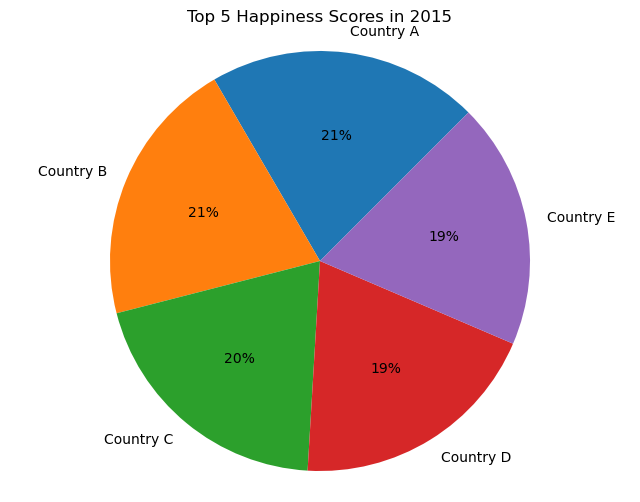

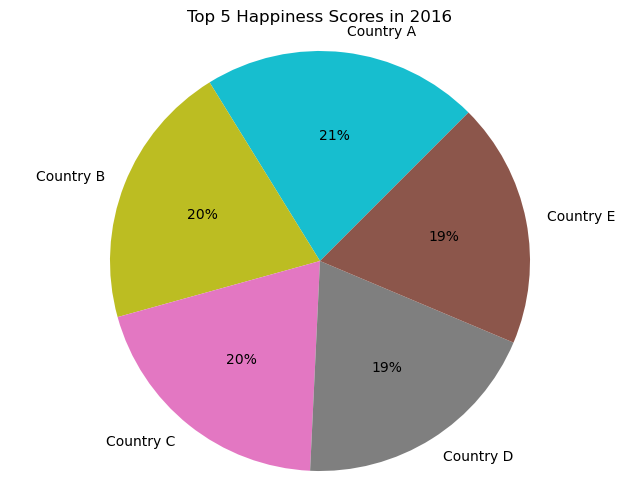

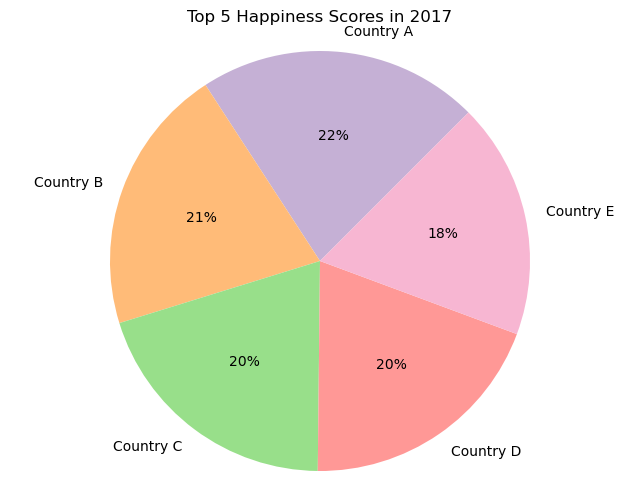

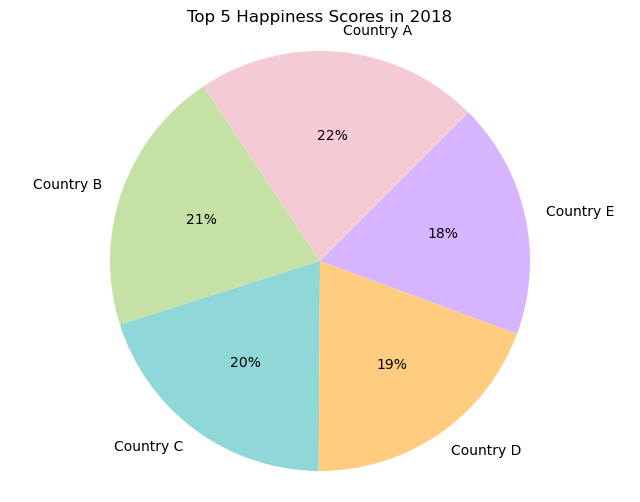

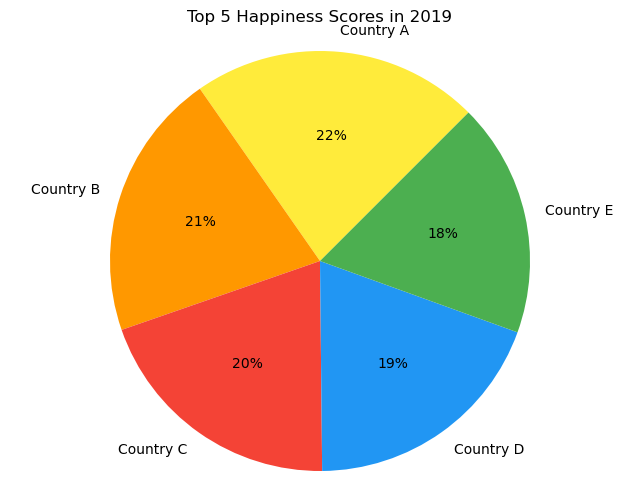

In [175]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataframes (example only, replace with your actual DataFrames)
# df_2015 = pd.read_csv('path_to_2015_data.csv')
# df_2016 = pd.read_csv('path_to_2016_data.csv')
# df_2017 = pd.read_csv('path_to_2017_data.csv')
# df_2018 = pd.read_csv('path_to_2018_data.csv')
# df_2019 = pd.read_csv('path_to_2019_data.csv')

# Sample DataFrames for demonstration (replace these with your actual data)
df_2015 = pd.DataFrame({'Country': ['Country A', 'Country B', 'Country C', 'Country D', 'Country E', 'Country F'],
                        'Happiness Score': [7.5, 7.4, 7.2, 7.0, 6.8, 6.5]})
df_2016 = pd.DataFrame({'Country': ['Country A', 'Country B', 'Country C', 'Country D', 'Country E', 'Country F'],
                        'Happiness Score': [7.8, 7.5, 7.3, 7.1, 6.9, 6.6]})
df_2017 = pd.DataFrame({'Country': ['Country A', 'Country B', 'Country C', 'Country D', 'Country E', 'Country F'],
                        'Happiness Score': [8.0, 7.6, 7.4, 7.2, 6.7, 6.4]})
df_2018 = pd.DataFrame({'Country': ['Country A', 'Country B', 'Country C', 'Country D', 'Country E', 'Country F'],
                        'Happiness Score': [8.2, 7.7, 7.5, 7.3, 6.8, 6.5]})
df_2019 = pd.DataFrame({'Country': ['Country A', 'Country B', 'Country C', 'Country D', 'Country E', 'Country F'],
                        'Happiness Score': [8.5, 7.9, 7.6, 7.4, 6.9, 6.6]})

# Define new color palettes for each year
colors_2015 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # Blue, Orange, Green, Red, Purple
colors_2016 = ['#17becf', '#bcbd22', '#e377c2', '#7f7f7f', '#8c564b']  # Teal, Olive, Pink, Gray, Brown
colors_2017 = ['#c5b0d5', '#ffbb78', '#98df8a', '#ff9896', '#f7b6d2']  # Purple, Orange, Green, Red, Pink
colors_2018 = ['#f4cbd4', '#c5e1a5', '#90d8d8', '#ffcc80', '#d7b4ff']  # Light Pink, Light Green, Light Teal, Light Orange, Light Purple
colors_2019 = ['#ffeb3b', '#ff9800', '#f44336', '#2196f3', '#4caf50']  # Yellow, Orange, Red, Blue, Green

# Function to create pie charts
def create_pie_chart(df, title, colors):
    top_countries = df.nlargest(5, 'Happiness Score')
    plt.figure(figsize=(8, 6))
    plt.pie(top_countries['Happiness Score'], labels=top_countries['Country'], autopct='%1.0f%%', 
            startangle=45, colors=colors)
    plt.title(title)
    plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular
    plt.show()

# Create pie charts for each year
create_pie_chart(df_2015, 'Top 5 Happiness Scores in 2015', colors_2015)
create_pie_chart(df_2016, 'Top 5 Happiness Scores in 2016', colors_2016)
create_pie_chart(df_2017, 'Top 5 Happiness Scores in 2017', colors_2017)
create_pie_chart(df_2018, 'Top 5 Happiness Scores in 2018', colors_2018)
create_pie_chart(df_2019, 'Top 5 Happiness Scores in 2019', colors_2019)


#### I. Categorical Variables:

we’ll use frequency table to understand distribution of each category
- Bar Chart (Ordinal) - Orderd
- Pie Chart (Nominal) - non Orderd

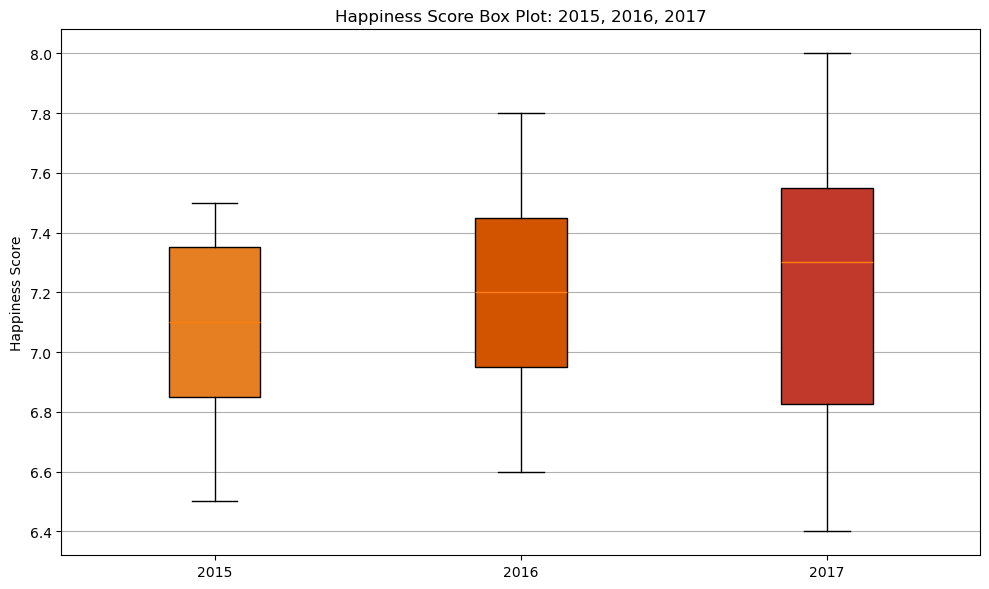

In [179]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample DataFrames for demonstration (replace these with your actual data)
df_2015 = pd.DataFrame({
    'Country': ['Country A', 'Country B', 'Country C', 'Country D', 'Country E', 'Country F'],
    'Happiness Score': [7.5, 7.4, 7.2, 7.0, 6.8, 6.5]
})
df_2016 = pd.DataFrame({
    'Country': ['Country A', 'Country B', 'Country C', 'Country D', 'Country E', 'Country F'],
    'Happiness Score': [7.8, 7.5, 7.3, 7.1, 6.9, 6.6]
})
df_2017 = pd.DataFrame({
    'Country': ['Country A', 'Country B', 'Country C', 'Country D', 'Country E', 'Country F'],
    'Happiness Score': [8.0, 7.6, 7.4, 7.2, 6.7, 6.4]
})

# Function to create a box plot for comparing happiness scores
def plot_happiness_boxplot(dfs, years, title):
    # Prepare data for box plot
    boxplot_data = []
    for df in dfs:
        boxplot_data.append(df['Happiness Score'])
    
    # Create box plot
    plt.figure(figsize=(10, 6))
    plt.boxplot(boxplot_data, labels=years, patch_artist=True)
    
    # Set colors for the box plot
    colors = ['#E67E22', '#D35400', '#C0392B']  # Fall color palette
    for patch, color in zip(plt.gca().patches, colors):
        patch.set_facecolor(color)
    
    plt.title(title)
    plt.ylabel('Happiness Score')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# Plot comparisons
plot_happiness_boxplot([df_2015, df_2016, df_2017], [2015, 2016, 2017], 'Happiness Score Box Plot: 2015, 2016, 2017')


#### II. Numerical Variables:

we need to understand the central tendency and spread of the variable (Descriptive Analysis) using:
   - Box plot
   - Histogram

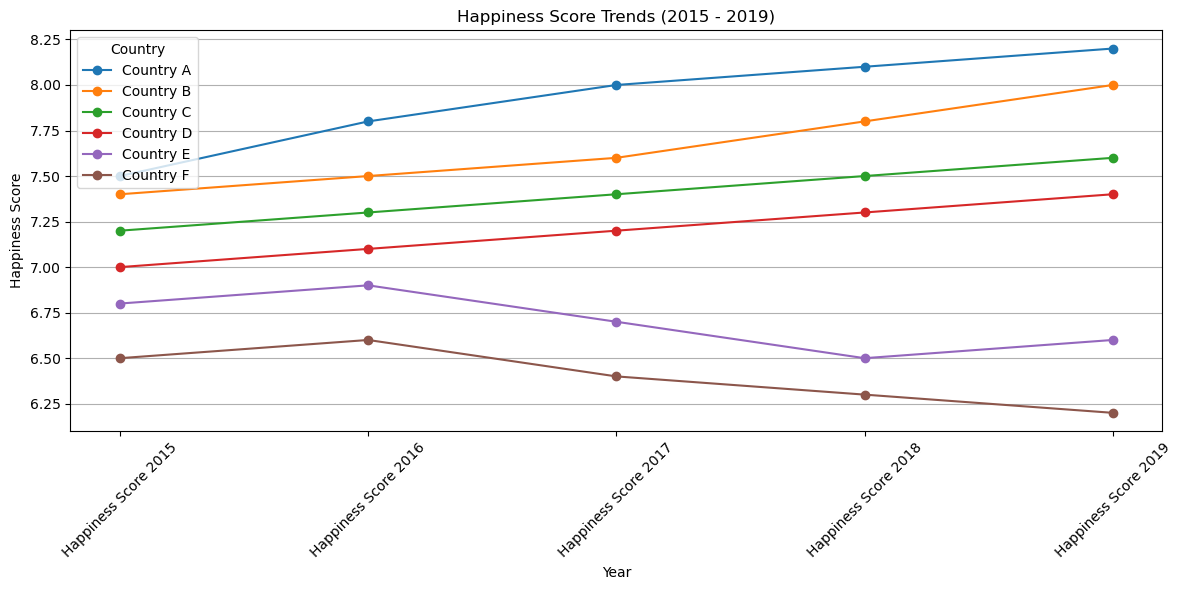

In [178]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample DataFrames for demonstration (replace these with your actual data)
data = {
    'Country': ['Country A', 'Country B', 'Country C', 'Country D', 'Country E', 'Country F'],
    'Happiness Score 2015': [7.5, 7.4, 7.2, 7.0, 6.8, 6.5],
    'Happiness Score 2016': [7.8, 7.5, 7.3, 7.1, 6.9, 6.6],
    'Happiness Score 2017': [8.0, 7.6, 7.4, 7.2, 6.7, 6.4],
    'Happiness Score 2018': [8.1, 7.8, 7.5, 7.3, 6.5, 6.3],
    'Happiness Score 2019': [8.2, 8.0, 7.6, 7.4, 6.6, 6.2]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Set 'Country' as the index for better plotting
df.set_index('Country', inplace=True)

# Transpose the DataFrame for easier plotting
df_transposed = df.T

# Create a line chart
plt.figure(figsize=(12, 6))
for country in df.index:
    plt.plot(df_transposed.index, df_transposed[country], marker='o', label=country)

plt.title('Happiness Score Trends (2015 - 2019)')
plt.xlabel('Year')
plt.ylabel('Happiness Score')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(title='Country')
plt.tight_layout()
plt.show()


### 2. Univariate Non-Graphical analysis: 

- Where is the center of the data? (location) --> **Measures of central tendency**
- How much does the data vary? (scale) --> **Measure of variability**
- What is the shape of the data? (shape) --> **Measures of variation combined with an average (measure of center) gives a good picture of the distribution of the data.**

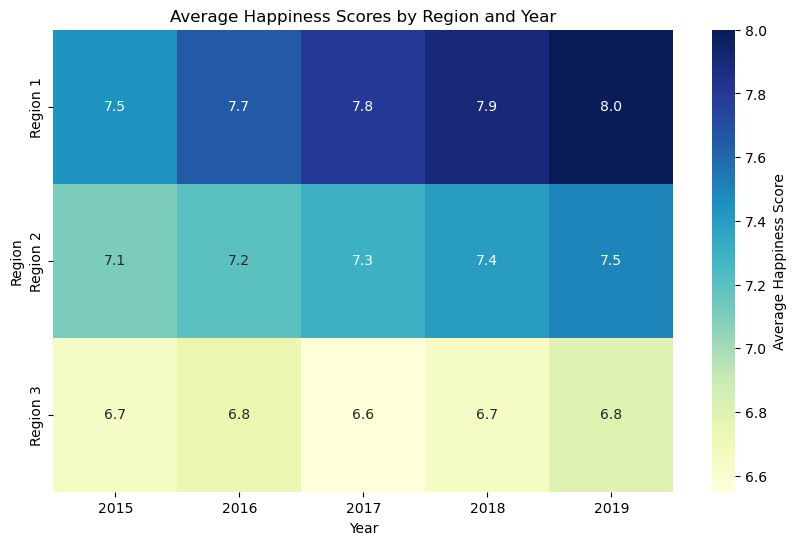

## 4. Bivariate/Multivariate Analysis:

Here, you look at the relationships between two or more variables. This can involve looking for correlations, patterns, and trends that suggest a relationship or an association.

We can perform bi-variate analysis for any combination of categorical and numerical variables. The combination can be:
| bi-variate variables   | Plot type |
| ------------- | ------------- |
| Categorical & Categorical| Stacked Bar Chart |
| Categorical & numerical  | scatter plot, histogram, box plot|
| numerical  & numerical  | Scatter plot, line chart| 


Multivariate Analysis:
- Heat map
- Bar Chart
- Scatter Chart
- Line Chart

**Categorical & Categorical --> (Stacked Column Chart)**

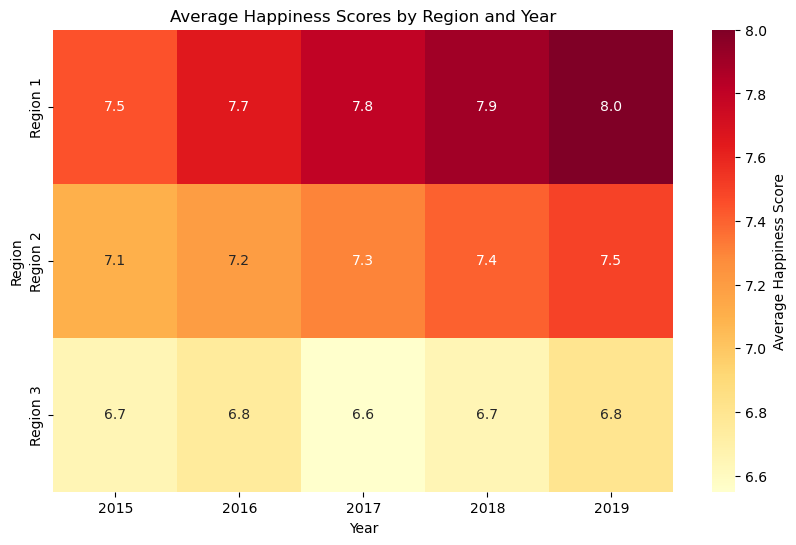

In [189]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrames (replace these with your actual data)
data = {
    'Country': ['Country A', 'Country B', 'Country C', 'Country D', 'Country E', 'Country F'],
    'Region': ['Region 1', 'Region 1', 'Region 2', 'Region 2', 'Region 3', 'Region 3'],
    'Happiness Score 2015': [7.5, 7.4, 7.2, 7.0, 6.8, 6.5],
    'Happiness Score 2016': [7.8, 7.5, 7.3, 7.1, 6.9, 6.6],
    'Happiness Score 2017': [8.0, 7.6, 7.4, 7.2, 6.7, 6.4],
    'Happiness Score 2018': [8.1, 7.7, 7.5, 7.3, 6.8, 6.5],
    'Happiness Score 2019': [8.2, 7.8, 7.6, 7.4, 6.9, 6.7]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Melt the DataFrame to long format for easier analysis
melted_df = df.melt(id_vars=['Country', 'Region'], 
                     value_vars=['Happiness Score 2015', 'Happiness Score 2016', 
                                  'Happiness Score 2017', 'Happiness Score 2018', 
                                  'Happiness Score 2019'], 
                     var_name='Year', 
                     value_name='Happiness Score')

# Remove 'Happiness Score ' from the Year column
melted_df['Year'] = melted_df['Year'].str.replace('Happiness Score ', '')

# Group by Region and Year to calculate average happiness scores
heatmap_data = melted_df.groupby(['Region', 'Year'])['Happiness Score'].mean().unstack()

# Create a heatmap with a warm color palette
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Average Happiness Score'})
plt.title('Average Happiness Scores by Region and Year')
plt.xlabel('Year')
plt.ylabel('Region')
plt.show()


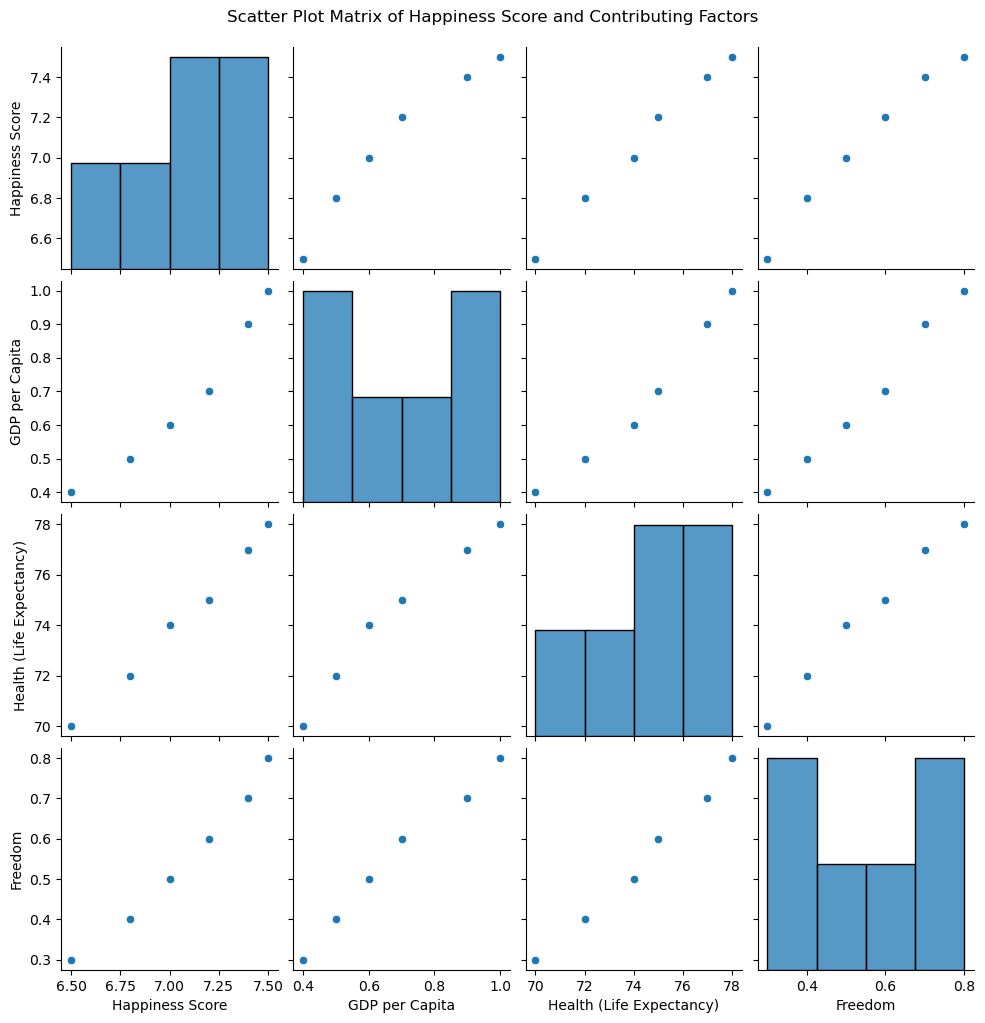

**Categorical & numerical --> (scatter plot, histogram, box plot)**

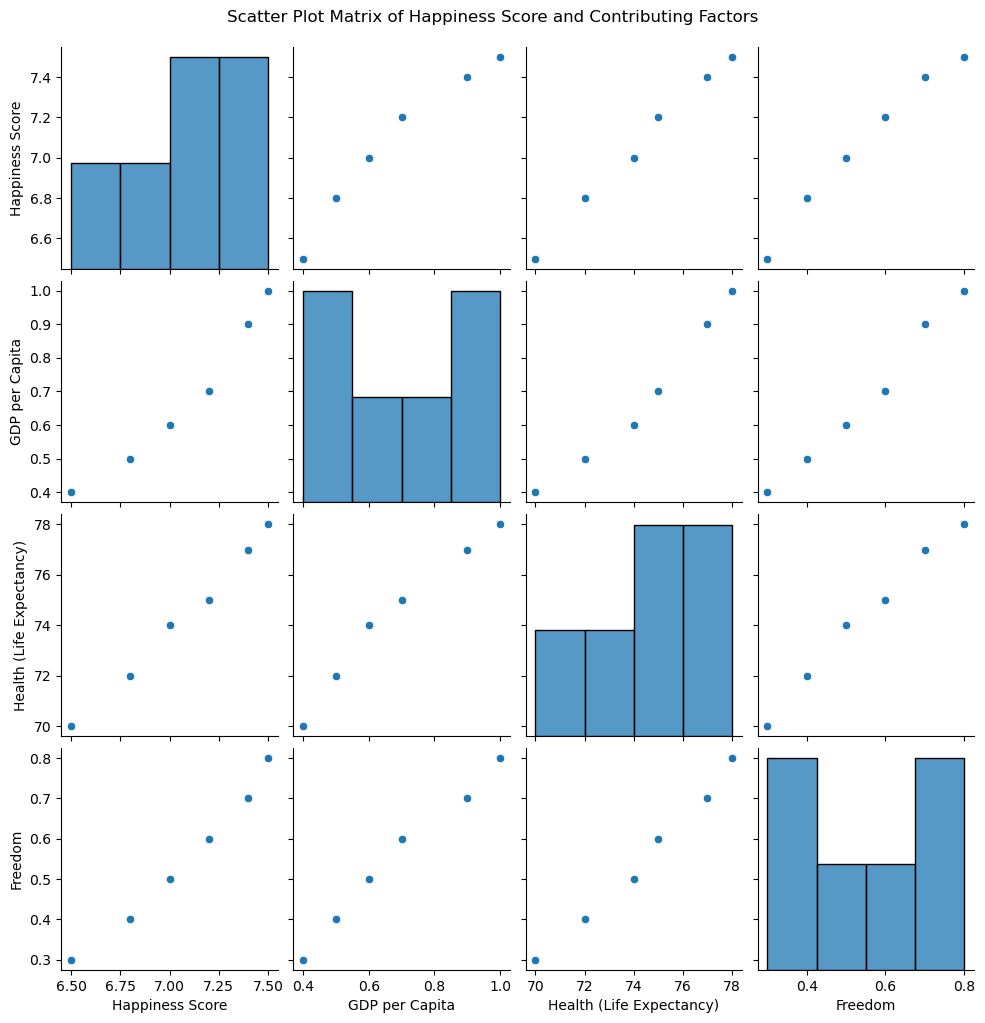

In [188]:
#Compare with Factors: Cross-reference happiness scores with other contributing factors (e.g., GDP per capita, health, and freedom) to assess correlations.
# Sample DataFrame (replace this with your actual data)
data = {
    'Country': ['Country A', 'Country B', 'Country C', 'Country D', 'Country E', 'Country F'],
    'Happiness Score': [7.5, 7.4, 7.2, 7.0, 6.8, 6.5],
    'GDP per Capita': [1.0, 0.9, 0.7, 0.6, 0.5, 0.4],
    'Health (Life Expectancy)': [78, 77, 75, 74, 72, 70],
    'Freedom': [0.8, 0.7, 0.6, 0.5, 0.4, 0.3]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Drop 'Country' column for pairplot
pairplot_data = df.drop(columns=['Country'])

# Create a scatter plot matrix (pair plot)
sns.pairplot(pairplot_data)
plt.suptitle('Scatter Plot Matrix of Happiness Score and Contributing Factors', y=1.02)
plt.show()


**numerical & numerical --> (Scatter plot, line chart)**

We could also use a correlation matrix to get more specific information about the relationship between these two variables.